In [51]:
import os, re, random, warnings
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F          # ← NEW
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

device = "cuda" if torch.cuda.is_available() else "cpu"
print("=" * 40)
print("Device :", device)
if device == "cuda":
    print("GPU :", torch.cuda.get_device_name(0))
    print("VRAM :", round(torch.cuda.get_device_properties(0).total_memory/1e9,1), "GB")
else:
    print("⚠️ No GPU — go to Settings → Accelerator → GPU then restart kernel")
print("=" * 40)


Device : cuda
GPU : Tesla T4
VRAM : 15.6 GB


In [52]:
CFG = dict(
    data_root    = "/kaggle/input/datasets/adham7elmy/faceforencispp-extracted-frames",
    fake_method  = "Deepfakes",
    savedir      = "/kaggle/working",

    num_frames   = 16,
    img_size     = 224,

    batch_size   = 4,       # keep 4 for memory
    num_workers  = 0,
    pin_memory   = False,
    accum_steps  = 4,       # ← increase to 4 (effective batch = 16, same as before)

    dropout      = 0.3,
    epochs       = 10,
    patience     = 4,       # ← increase patience slightly
    lr_cnn       = 3e-5,    # ← was 1e-5
    lr_head      = 3e-4,    # ← was 1e-3

    use_frac     = 1.0,     # ← back to full dataset (memory fine with batch=4)
)


Path(CFG["savedir"]).mkdir(parents=True, exist_ok=True)
print("Config ready ✅")


Config ready ✅


In [53]:
DATA = Path(CFG["data_root"])

def build_manifest(data_root, fake_method):
    rows = []

    # ── FAKE: fake/<method>/<vid_id>/ ──────────────────────
    fake_dir = data_root / "fake" / fake_method
    for vid_dir in sorted(fake_dir.iterdir()):
        if not vid_dir.is_dir(): continue
        frames = sorted(vid_dir.glob("*.png")) + sorted(vid_dir.glob("*.jpg"))
        if len(frames) < CFG["num_frames"]: continue
        rows.append({"vid_id": vid_dir.name, "label": 1,
                     "frames": [str(f) for f in frames], "method": fake_method})

    # ── REAL: real/000, real/001, ... ──────────────────────
    real_root = data_root / "real"
    for vid_dir in sorted(real_root.iterdir()):
        if not vid_dir.is_dir(): continue
        frames = sorted(vid_dir.glob("*.png")) + sorted(vid_dir.glob("*.jpg"))
        if len(frames) < CFG["num_frames"]: continue
        rows.append({"vid_id": vid_dir.name, "label": 0,
                     "frames": [str(f) for f in frames], "method": "real"})

    return pd.DataFrame(rows)

df = build_manifest(DATA, CFG["fake_method"])
print("Total videos (full):", len(df))
print(df["label"].value_counts().rename({0:"real", 1:"fake"}))

# 30% subsample
df = df.sample(frac=CFG["use_frac"], random_state=SEED).reset_index(drop=True)
print(f"\nAfter {CFG['use_frac']*100:.0f}% sample → {len(df)} videos")
print(df["label"].value_counts().rename({0:"real", 1:"fake"}))

Total videos (full): 1996
label
real    999
fake    997
Name: count, dtype: int64

After 100% sample → 1996 videos
label
real    999
fake    997
Name: count, dtype: int64


In [54]:
tr_df, tmp   = train_test_split(df,  test_size=0.30,
                                stratify=df["label"],  random_state=SEED)
va_df, te_df = train_test_split(tmp, test_size=0.40,
                                stratify=tmp["label"], random_state=SEED)

print(f"Train : {len(tr_df):4d}  (fake={int(tr_df['label'].sum())})")
print(f"Val   : {len(va_df):4d}  (fake={int(va_df['label'].sum())})")
print(f"Test  : {len(te_df):4d}  (fake={int(te_df['label'].sum())})")

Train : 1397  (fake=698)
Val   :  359  (fake=179)
Test  :  240  (fake=120)


In [55]:
train_tfm = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tfm = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class FFImageSeqDataset(Dataset):
    def __init__(self, df, num_frames=16, transform=None):
        self.df         = df.reset_index(drop=True)
        self.num_frames = num_frames
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        pool = row["frames"]
        idxs = np.linspace(0, len(pool)-1, self.num_frames).astype(int)
        imgs = []
        for i in idxs:
            try:
                img = Image.open(pool[i]).convert("RGB")
            except Exception:
                img = Image.new("RGB", (CFG["img_size"], CFG["img_size"]), 0)
            imgs.append(self.transform(img) if self.transform else T.ToTensor()(img))
        x = torch.stack(imgs)   # (T, 3, H, W)
        y = torch.tensor(row["label"], dtype=torch.float32)
        return x, y

# num_workers=0 and pin_memory=False ← critical fix
train_loader = DataLoader(
    FFImageSeqDataset(tr_df, CFG["num_frames"], train_tfm),
    batch_size  = CFG["batch_size"],
    shuffle     = True,
    num_workers = 0,
    pin_memory  = False
)
val_loader = DataLoader(
    FFImageSeqDataset(va_df, CFG["num_frames"], val_tfm),
    batch_size  = CFG["batch_size"],
    shuffle     = False,
    num_workers = 0,
    pin_memory  = False
)
test_loader = DataLoader(
    FFImageSeqDataset(te_df, CFG["num_frames"], val_tfm),
    batch_size  = CFG["batch_size"],
    shuffle     = False,
    num_workers = 0,
    pin_memory  = False
)

# shape check
xb, yb = next(iter(train_loader))
print("✅ Batch shape:", xb.shape)   # expect (8, 16, 3, 224, 224)
print("   Labels     :", yb)

✅ Batch shape: torch.Size([4, 16, 3, 224, 224])
   Labels     : tensor([0., 1., 1., 0.])


In [56]:
class SAM(torch.optim.Optimizer):
    """Sharpness-Aware Minimization (Foret et al., 2021)."""
    def __init__(self, params, base_optimizer=torch.optim.AdamW, rho=0.05, **kwargs):
        assert rho >= 0.0
        defaults = dict(rho=rho, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups   = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                e_w = p.grad * scale.to(p)
                p.add_(e_w)
                self.state[p]["e_w"] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.sub_(self.state[p]["e_w"])
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        norm = torch.norm(
            torch.stack([
                p.grad.norm(p=2).to(shared_device)
                for group in self.param_groups
                for p in group["params"]
                if p.grad is not None
            ]), p=2)
        return norm

    def load_state_dict(self, state_dict):
        super().load_state_dict(state_dict)
        self.base_optimizer.param_groups = self.param_groups

print("✅ SAM Optimizer defined")

class WeightedBCELoss(nn.Module):
    """
    Standard BCE for balanced data.
    pos_weight > 1 slightly upweights fake class if imbalanced.
    """
    def __init__(self, pos_weight=1.0):
        super().__init__()
        pw = torch.tensor([pos_weight])
        self.loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)

    def forward(self, logits, targets):
        return self.loss_fn(logits.cpu(), targets.cpu())

print("✅ WeightedBCELoss defined")

class FrequencyFeatureAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 16)),
            nn.GELU(),
            nn.Linear(max(channels // reduction, 16), channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        x_f    = x.float()                                          # ensure float32 for FFT
        fft_c  = torch.fft.rfft2(x_f)
        fft_mag = (fft_c.real**2 + fft_c.imag**2 + 1e-8).sqrt()   # safe magnitude
        fft_vec = fft_mag.mean(dim=(-2, -1))                        # (B, C)
        # Normalize so FC input is always in [0,1] range
        fft_vec = fft_vec / (fft_vec.amax(dim=1, keepdim=True) + 1e-8)
        attn    = self.fc(fft_vec).to(x.dtype).unsqueeze(-1).unsqueeze(-1)
        return x * attn


class FeaturePyramidFusion(nn.Module):
    def __init__(self, out_dim=512):
        super().__init__()
        self.proj2 = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                   nn.Linear(512,  out_dim), nn.LayerNorm(out_dim))
        self.proj3 = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                   nn.Linear(1024, out_dim), nn.LayerNorm(out_dim))
        self.proj4 = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                   nn.Linear(2048, out_dim), nn.LayerNorm(out_dim))
        self.scale_weights = nn.Parameter(torch.ones(3) / 3.0)

    def forward(self, f2, f3, f4):
        w  = torch.softmax(self.scale_weights, dim=0)
        return w[0]*self.proj2(f2) + w[1]*self.proj3(f3) + w[2]*self.proj4(f4)


class DifferenceCNN(nn.Module):
    def __init__(self, out_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),  nn.BatchNorm2d(32),  nn.GELU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64),  nn.GELU(),
            nn.Conv2d(64,128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, out_dim),
            nn.LayerNorm(out_dim)
        )

    def forward(self, x):
        return self.net(x)


class TemporalTransformerWithDiffTokens(nn.Module):
    def __init__(self, dim=512, nhead=8, num_layers=2, max_seq=32, dropout=0.1):
        super().__init__()
        self.cls_token  = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed  = nn.Parameter(torch.randn(1, max_seq + 1, dim) * 0.02)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=dim, nhead=nhead, dim_feedforward=dim * 4,
            dropout=dropout, activation='gelu', batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm        = nn.LayerNorm(dim)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, frame_feats, diff_feats):
        B      = frame_feats.size(0)
        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, frame_feats, diff_feats], dim=1)
        tokens = tokens + self.pos_embed[:, :tokens.size(1), :]
        out    = self.transformer(tokens)
        return self.norm(out[:, 0])

print("✅ All model components defined")

class MFTDNet(nn.Module):
    def __init__(self, num_frames=16, feat_dim=256, dropout=0.3):  # ← 512→256
        super().__init__()
        self.num_frames = num_frames
        self.feat_dim   = feat_dim

        bb = torchvision.models.resnext50_32x4d(weights="IMAGENET1K_V2")
        self.stem   = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.layer1 = bb.layer1
        self.layer2 = bb.layer2
        self.layer3 = bb.layer3
        self.layer4 = bb.layer4

        for p in list(self.stem.parameters()) + list(self.layer1.parameters()):
            p.requires_grad = False

        self.fpn      = FeaturePyramidFusion(out_dim=feat_dim)
        self.ffm      = FrequencyFeatureAttention(channels=2048)
        self.diff_cnn = DifferenceCNN(out_dim=feat_dim)
        self.temporal = TemporalTransformerWithDiffTokens(
            dim=feat_dim,
            nhead=4,         # ← 8→4
            num_layers=1,    # ← 2→1
            max_seq=num_frames + (num_frames - 1))

        self.head = nn.Sequential(
            nn.Linear(feat_dim, 128),  # ← 256→128
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        imgs = x.view(B * T, C, H, W)

        s  = self.stem(imgs)
        l1 = self.layer1(s)
        l2 = self.layer2(l1)
        l3 = self.layer3(l2)
        l4 = self.layer4(l3)

        frame_feats = self.fpn(l2, l3, l4)

        l4_attn   = self.ffm(l4)
        freq_gate = torch.sigmoid(
            l4_attn.mean(dim=(-2, -1)).mean(dim=1, keepdim=True))
        frame_feats = frame_feats * freq_gate
        frame_feats = frame_feats.view(B, T, self.feat_dim)

        f_curr     = x[:, 1:].reshape(B*(T-1), C, H, W)
        f_prev     = x[:, :-1].reshape(B*(T-1), C, H, W)
        diff_feats = self.diff_cnn(torch.abs(f_curr - f_prev))
        diff_feats = diff_feats.view(B, T-1, self.feat_dim)

        cls_out = self.temporal(frame_feats, diff_feats)
        return self.head(cls_out).squeeze(-1)


# Clear old model from GPU first
if 'model' in dir():
    del model
torch.cuda.empty_cache()

model     = MFTDNet(num_frames=CFG["num_frames"], feat_dim=256, dropout=CFG["dropout"]).to(device)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total/1e6:.2f}M")
print(f"Trainable params: {trainable/1e6:.2f}M")

with torch.no_grad():
    dummy = torch.randn(2, CFG["num_frames"], 3,
                        CFG["img_size"], CFG["img_size"]).to(device)
    out = model(dummy)
    print(f"✅ Forward pass OK — output shape: {out.shape}")
    print(f"   NaN in output: {torch.isnan(out).any().item()}")
    del dummy
torch.cuda.empty_cache()


✅ SAM Optimizer defined
✅ WeightedBCELoss defined
✅ All model components defined
Total params    : 25.39M
Trainable params: 25.17M
✅ Forward pass OK — output shape: torch.Size([2])
   NaN in output: False


In [57]:
backbone_params   = (list(model.stem.parameters())   +
                     list(model.layer1.parameters())  +
                     list(model.layer2.parameters())  +
                     list(model.layer3.parameters())  +
                     list(model.layer4.parameters()))

new_module_params = (list(model.fpn.parameters())      +
                     list(model.ffm.parameters())       +
                     list(model.diff_cnn.parameters())  +
                     list(model.temporal.parameters())  +
                     list(model.head.parameters()))

optimizer = torch.optim.AdamW(
    [
        {"params": [p for p in backbone_params   if p.requires_grad], "lr": 3e-5},  # ← was 1e-5
        {"params": [p for p in new_module_params if p.requires_grad], "lr": 3e-4},  # ← was 1e-3
    ],
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG["epochs"], eta_min=1e-6)

criterion = WeightedBCELoss(pos_weight=1.0)   # ← replaces FocalLoss
scaler    = GradScaler()

print("✅ AdamW + CosineAnnealingLR + WeightedBCE ready")


✅ AdamW + CosineAnnealingLR + WeightedBCE ready


In [58]:
def run_epoch(loader, train=True):
    model.train(train)
    total_loss   = 0.0
    all_y, all_p = [], []

    pbar = tqdm(enumerate(loader), total=len(loader),
                desc="Train" if train else "Val  ", leave=False)

    for step, (x, y) in pbar:
        x = x.to(device)
        y = y.to(device)

        with autocast():
            logit = model(x)
            loss  = criterion(logit, y)

        if train:
            scaler.scale(loss).backward()
            if (step + 1) % CFG["accum_steps"] == 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

        prob = torch.sigmoid(logit).detach().float().cpu().numpy()
        total_loss += loss.item()
        all_p.extend(prob.tolist())
        all_y.extend(y.detach().float().cpu().numpy().tolist())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    y_true = np.array(all_y)
    y_prob = np.array(all_p)
    y_pred = (y_prob >= 0.5).astype(int)
    return dict(
        loss = total_loss / len(loader),
        acc  = accuracy_score(y_true, y_pred),
        f1   = f1_score(y_true, y_pred, zero_division=0),
        auc  = roc_auc_score(y_true, y_prob)
               if len(np.unique(y_true)) > 1 else float("nan")
    )

# ── Main loop ──────────────────────────────────────────────────────────────────
torch.cuda.empty_cache()
best_auc   = 0.0
no_improve = 0
history    = []
save_path  = Path(CFG["savedir"]) / "best_mftdnet.pt"

print(f"{'Ep':>4} | {'TrLoss':>7} {'TrAcc':>6} {'TrAUC':>6}"
      f" | {'VaLoss':>7} {'VaAcc':>6} {'VaAUC':>6}")
print("─" * 55)

for epoch in range(1, CFG["epochs"] + 1):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader,   train=False)
    scheduler.step()

    history.append({"epoch": epoch,
                    **{f"tr_{k}": v for k, v in tr.items()},
                    **{f"va_{k}": v for k, v in va.items()}})

    print(f"{epoch:>4} | {tr['loss']:>7.4f} {tr['acc']:>6.3f} {tr['auc']:>6.3f}"
          f" | {va['loss']:>7.4f} {va['acc']:>6.3f} {va['auc']:>6.3f}")

    if va["auc"] > best_auc:
        best_auc   = va["auc"]
        no_improve = 0
        torch.save({"epoch": int(epoch),
                    "model_state": model.state_dict(),
                    "best_auc": float(best_auc)}, save_path)
        print(f"  ✅ Best saved (val AUC = {best_auc:.4f})")

print(f"\nTraining done. Best val AUC = {best_auc:.4f}")

  Ep |  TrLoss  TrAcc  TrAUC |  VaLoss  VaAcc  VaAUC
───────────────────────────────────────────────────────


Train:   0%|          | 0/350 [00:00<?, ?it/s]

Val  :   0%|          | 0/90 [00:00<?, ?it/s]

   1 |  0.7035  0.500  0.517 |  0.6005  0.610  0.927
  ✅ Best saved (val AUC = 0.9270)


Train:   0%|          | 0/350 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/90 [00:00<?, ?it/s]

   9 |  0.0594  0.986  0.997 |  0.0358  0.992  0.997


Train:   0%|          | 0/350 [00:00<?, ?it/s]

Val  :   0%|          | 0/90 [00:00<?, ?it/s]

  10 |  0.0579  0.986  0.997 |  0.0539  0.992  0.997

Training done. Best val AUC = 0.9997


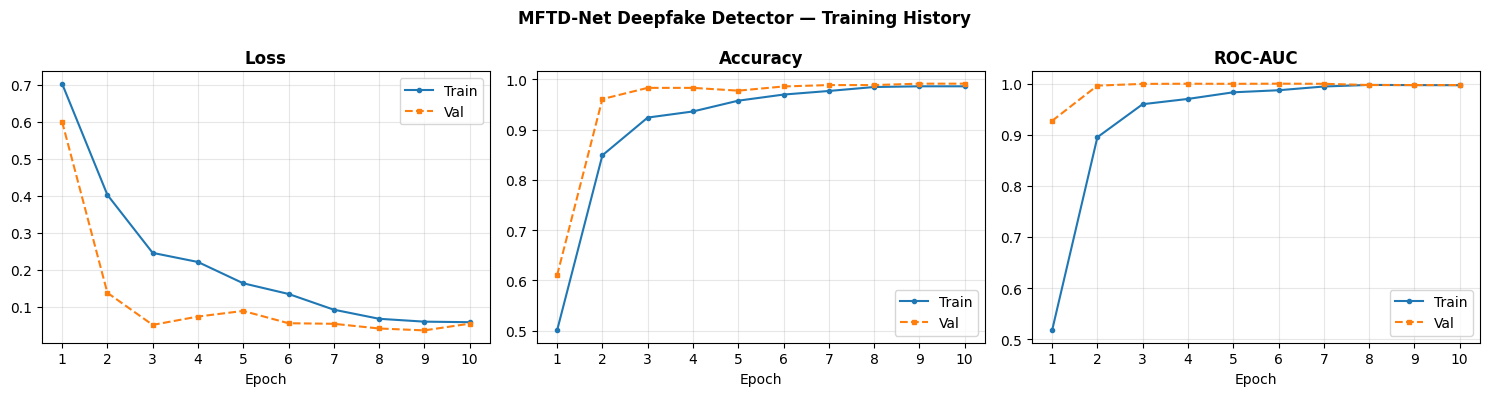

In [59]:
hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title in zip(axes,
        ["loss", "acc", "auc"], ["Loss", "Accuracy", "ROC-AUC"]):
    ax.plot(hist["epoch"], hist[f"tr_{metric}"], label="Train", marker="o", markersize=3)
    ax.plot(hist["epoch"], hist[f"va_{metric}"], label="Val",   marker="s", markersize=3,
            linestyle="--")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle("MFTD-Net Deepfake Detector — Training History", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['savedir']}/mftdnet_training_curves.png", dpi=120)
plt.show()

Loaded epoch 6  (val AUC = 0.9997)



Val  :   0%|          | 0/60 [00:00<?, ?it/s]


Test | Loss 0.1205  Acc 0.971  F1 0.970  AUC 0.9985


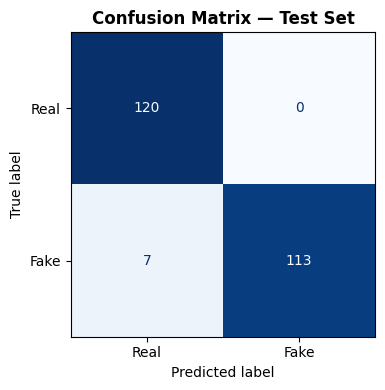

In [60]:
ckpt = torch.load(save_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded epoch {ckpt['epoch']}  (val AUC = {ckpt['best_auc']:.4f})\n")

te = run_epoch(test_loader, train=False)
print(f"\nTest | Loss {te['loss']:.4f}  Acc {te['acc']:.3f}  "
      f"F1 {te['f1']:.3f}  AUC {te['auc']:.4f}")

# Confusion matrix
all_y, all_p = [], []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        logit = model(x.to(device))
        prob  = torch.sigmoid(logit).cpu().numpy()
        all_p.extend(prob.tolist())
        all_y.extend(y.numpy().tolist())

y_true = np.array(all_y)
y_pred = (np.array(all_p) >= 0.5).astype(int)

cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['savedir']}/confusion_matrix.png", dpi=120)
plt.show()